Notebook này phân tích toàn diện bộ dữ liệu thương mại điện tử thời trang Việt Nam (2012–2022) theo bốn cấp độ:
- **Descriptive** — Chuyện gì đã xảy ra?
- **Diagnostic** — Tại sao nó xảy ra?
- **Predictive** — Điều gì có thể xảy ra tiếp theo?
- **Prescriptive** — Chúng ta nên làm gì?

In [1]:
# ── Core
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

# ── Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Stats
from scipy import stats
from scipy.stats import pearsonr

# ── Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans'
})

# ── Colour palette consistent with brand
PALETTE = ['#2196F3','#FF5722','#4CAF50','#FF9800','#9C27B0','#00BCD4']
print(' Libraries loaded')

 Libraries loaded


## 1. Load Dữ liệu

In [2]:
DATA_DIR = '../mycode/my_competition_data/'   # ← Thay bằng đường dẫn thư mục chứa CSV

# ── Master
products    = pd.read_csv(f'{DATA_DIR}products.csv')
customers   = pd.read_csv(f'{DATA_DIR}customers.csv', parse_dates=['signup_date'])
promotions  = pd.read_csv(f'{DATA_DIR}promotions.csv', parse_dates=['start_date','end_date'])
geography   = pd.read_csv(f'{DATA_DIR}geography.csv')

# ── Transaction
orders      = pd.read_csv(f'{DATA_DIR}orders.csv',      parse_dates=['order_date'])
order_items = pd.read_csv(f'{DATA_DIR}order_items.csv')
payments    = pd.read_csv(f'{DATA_DIR}payments.csv')
shipments   = pd.read_csv(f'{DATA_DIR}shipments.csv',   parse_dates=['ship_date','delivery_date'])
returns     = pd.read_csv(f'{DATA_DIR}returns.csv',      parse_dates=['return_date'])
reviews     = pd.read_csv(f'{DATA_DIR}reviews.csv',      parse_dates=['review_date'])

# ── Analytical
sales       = pd.read_csv(f'{DATA_DIR}sales.csv',        parse_dates=['Date'])

# ── Operational
inventory   = pd.read_csv(f'{DATA_DIR}inventory.csv',   parse_dates=['snapshot_date'])
web_traffic = pd.read_csv(f'{DATA_DIR}web_traffic.csv', parse_dates=['date'])

print(' Tất cả file đã load xong')
print(f"  Doanh thu train: {sales['Date'].min().date()} → {sales['Date'].max().date()}")
print(f"  Số đơn hàng   : {orders['order_id'].nunique():,}")
print(f"  Số khách hàng : {customers['customer_id'].nunique():,}")
print(f"  Số sản phẩm   : {products['product_id'].nunique():,}")

 Tất cả file đã load xong
  Doanh thu train: 2012-07-04 → 2022-12-31
  Số đơn hàng   : 646,945
  Số khách hàng : 121,930
  Số sản phẩm   : 2,412


## 2. Kiểm tra Chất lượng Dữ liệu (Data Quality)

In [3]:
def data_quality_report(df, name):
    """In báo cáo chất lượng dữ liệu cho một dataframe."""
    total = len(df)
    missing = df.isnull().sum()
    missing_pct = (missing / total * 100).round(2)
    dup = df.duplicated().sum()
    report = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.notnull().sum(),
        'missing': missing,
        'missing_%': missing_pct,
        'unique': df.nunique()
    })
    print(f"\n{'='*55}")
    print(f" {name}  — {total:,} dòng × {df.shape[1]} cột  |  Duplicates: {dup}")
    print('='*55)
    print(report[report['missing'] > 0].to_string() if report['missing'].sum() > 0
          else "   Không có giá trị thiếu")

for df, name in [
    (products, 'products'), (customers, 'customers'),
    (orders, 'orders'), (order_items, 'order_items'),
    (payments, 'payments'), (returns, 'returns'),
    (reviews, 'reviews'), (sales, 'sales'),
    (inventory, 'inventory'), (web_traffic, 'web_traffic')
]:
    data_quality_report(df, name)


 products  — 2,412 dòng × 8 cột  |  Duplicates: 0
   Không có giá trị thiếu

 customers  — 121,930 dòng × 7 cột  |  Duplicates: 0
   Không có giá trị thiếu

 orders  — 646,945 dòng × 8 cột  |  Duplicates: 0
   Không có giá trị thiếu

 order_items  — 714,669 dòng × 7 cột  |  Duplicates: 0
             dtype  non_null  missing  missing_%  unique
promo_id    object    276316   438353      61.34      50
promo_id_2  object       206   714463      99.97       2

 payments  — 646,945 dòng × 4 cột  |  Duplicates: 0
   Không có giá trị thiếu

 returns  — 39,939 dòng × 7 cột  |  Duplicates: 0
   Không có giá trị thiếu

 reviews  — 113,551 dòng × 7 cột  |  Duplicates: 0
   Không có giá trị thiếu

 sales  — 3,833 dòng × 3 cột  |  Duplicates: 0
   Không có giá trị thiếu

 inventory  — 60,247 dòng × 17 cột  |  Duplicates: 0
   Không có giá trị thiếu

 web_traffic  — 3,652 dòng × 7 cột  |  Duplicates: 0
   Không có giá trị thiếu


---
##  DESCRIPTIVE — Chuyện gì đã xảy ra?

### 3.1 Tổng quan Doanh thu theo thời gian

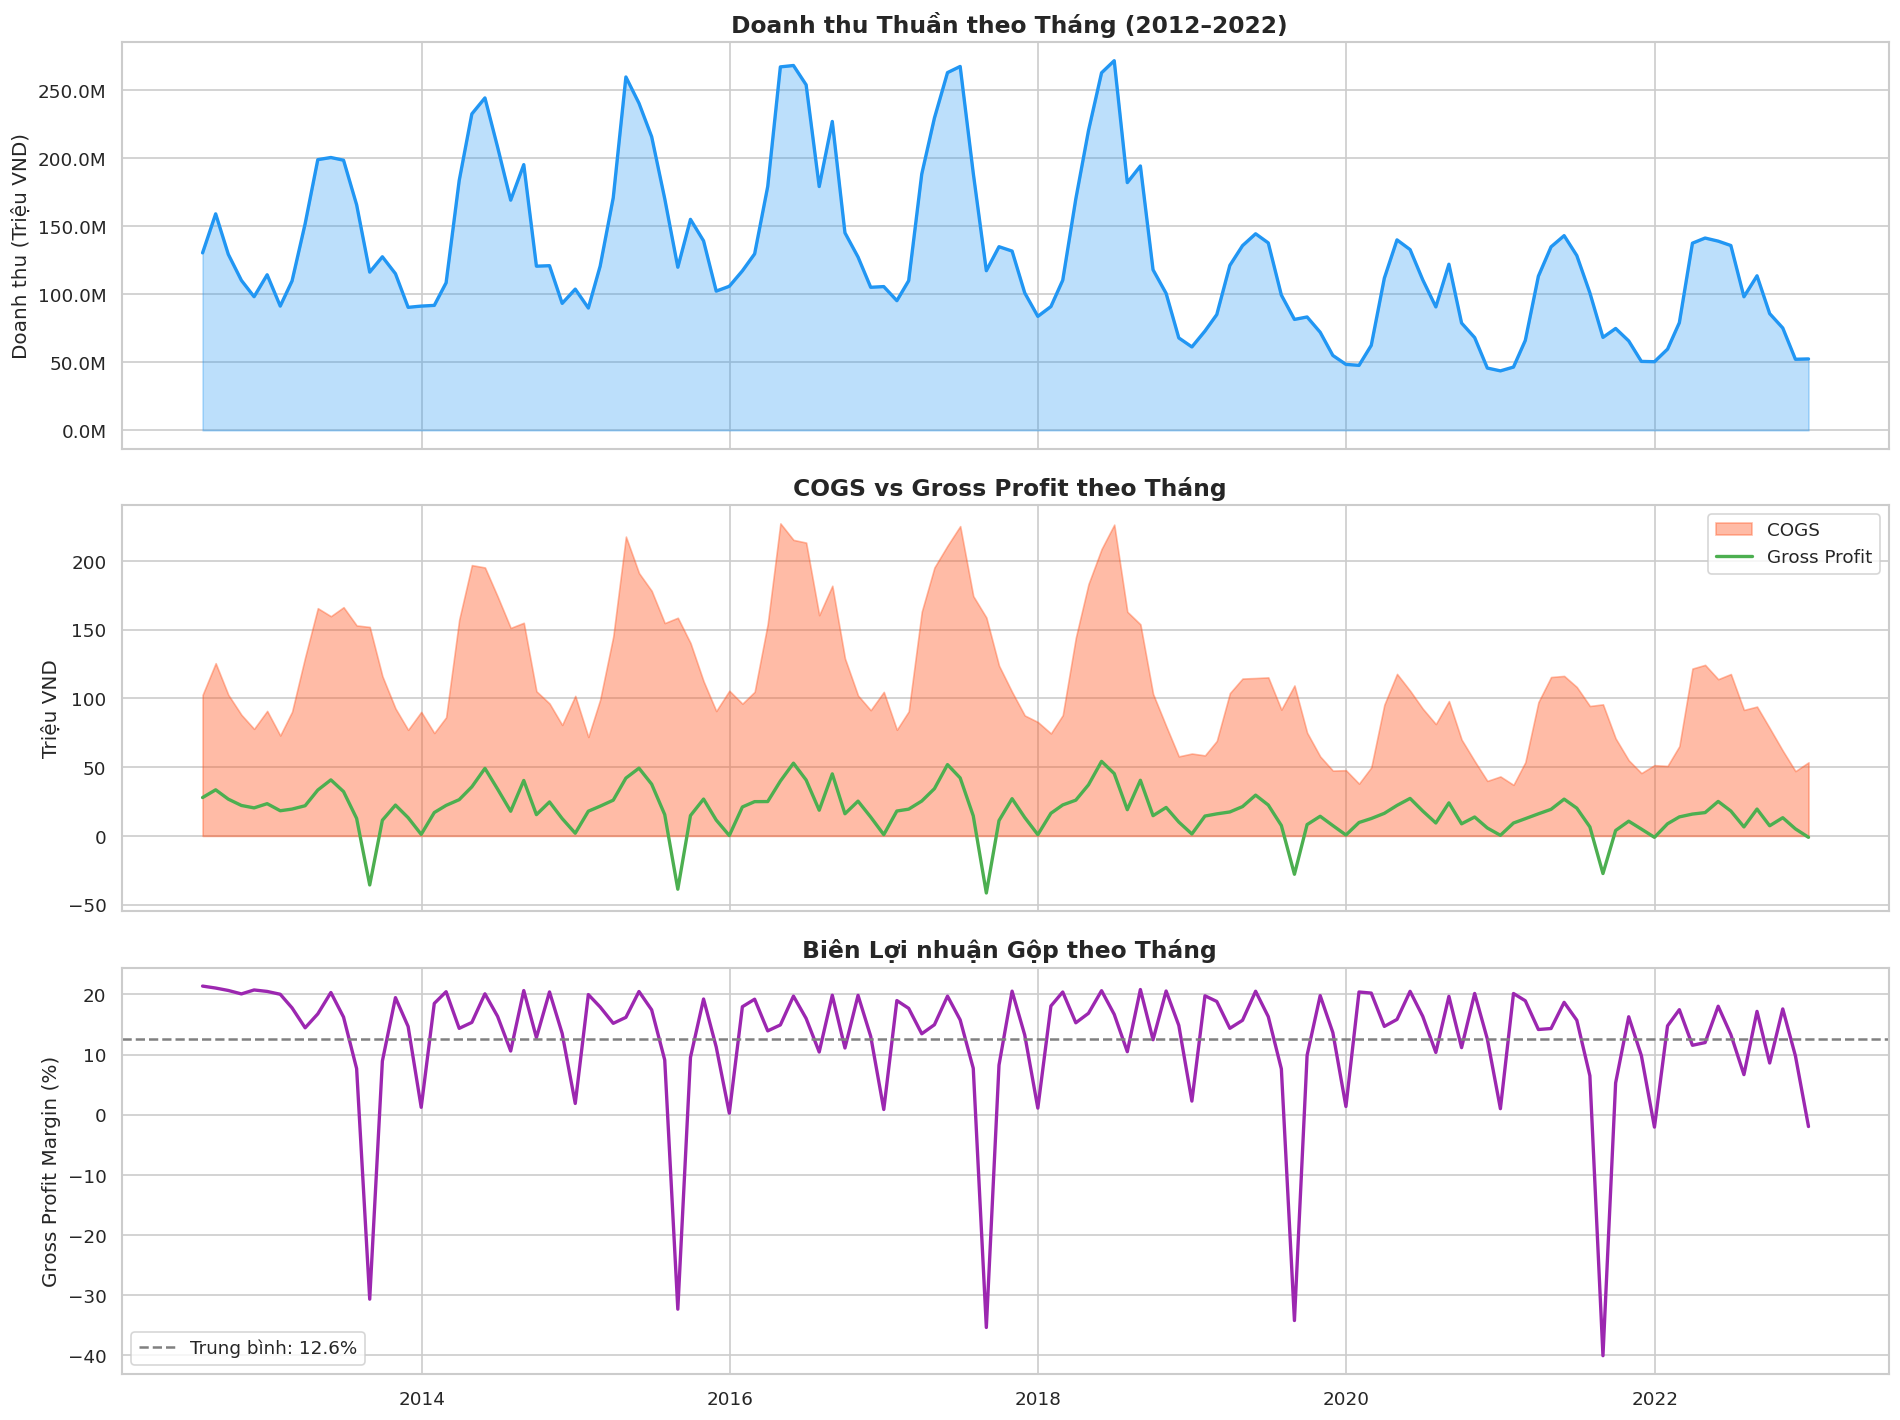


 Key Findings:
  Tổng doanh thu: 16.43 tỷ VND
  Tổng COGS     : 14.16 tỷ VND
  GP Margin TB  : 12.5%
  Ngày DT cao nhất: 2018-05-30 — 20,905,271 VND


In [4]:
# Thêm features thời gian
sales = sales.sort_values('Date').copy()
sales['year']  = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['dow']   = sales['Date'].dt.dayofweek  # 0=Mon
sales['gross_profit'] = sales['Revenue'] - sales['COGS']
sales['gp_margin']    = sales['gross_profit'] / sales['Revenue'] * 100

# Doanh thu tháng
monthly = sales.resample('M', on='Date').agg(
    Revenue=('Revenue','sum'),
    COGS=('COGS','sum'),
    GP=('gross_profit','sum')
).reset_index()
monthly['GP_margin'] = monthly['GP'] / monthly['Revenue'] * 100

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Revenue
axes[0].fill_between(monthly['Date'], monthly['Revenue']/1e6,
                     alpha=0.3, color='#2196F3')
axes[0].plot(monthly['Date'], monthly['Revenue']/1e6,
             color='#2196F3', linewidth=2)
axes[0].set_ylabel('Doanh thu (Triệu VND)')
axes[0].set_title(' Doanh thu Thuần theo Tháng (2012–2022)', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))

# COGS vs Revenue
axes[1].fill_between(monthly['Date'], monthly['COGS']/1e6,
                     alpha=0.4, color='#FF5722', label='COGS')
axes[1].plot(monthly['Date'], monthly['GP']/1e6,
             color='#4CAF50', linewidth=2, label='Gross Profit')
axes[1].set_ylabel('Triệu VND')
axes[1].set_title(' COGS vs Gross Profit theo Tháng', fontweight='bold')
axes[1].legend()

# GP Margin
axes[2].plot(monthly['Date'], monthly['GP_margin'],
             color='#9C27B0', linewidth=2)
axes[2].axhline(monthly['GP_margin'].mean(), linestyle='--',
                color='gray', label=f"Trung bình: {monthly['GP_margin'].mean():.1f}%")
axes[2].set_ylabel('Gross Profit Margin (%)')
axes[2].set_title(' Biên Lợi nhuận Gộp theo Tháng', fontweight='bold')
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('./eda_graph/fig01_revenue_overview.png', bbox_inches='tight')
plt.show()

print(f"\n Key Findings:")
print(f"  Tổng doanh thu: {sales['Revenue'].sum()/1e9:.2f} tỷ VND")
print(f"  Tổng COGS     : {sales['COGS'].sum()/1e9:.2f} tỷ VND")
print(f"  GP Margin TB  : {sales['gp_margin'].mean():.1f}%")
print(f"  Ngày DT cao nhất: {sales.loc[sales['Revenue'].idxmax(),'Date'].date()} — {sales['Revenue'].max():,.0f} VND")

### 3.2 Tính mùa vụ (Seasonality)

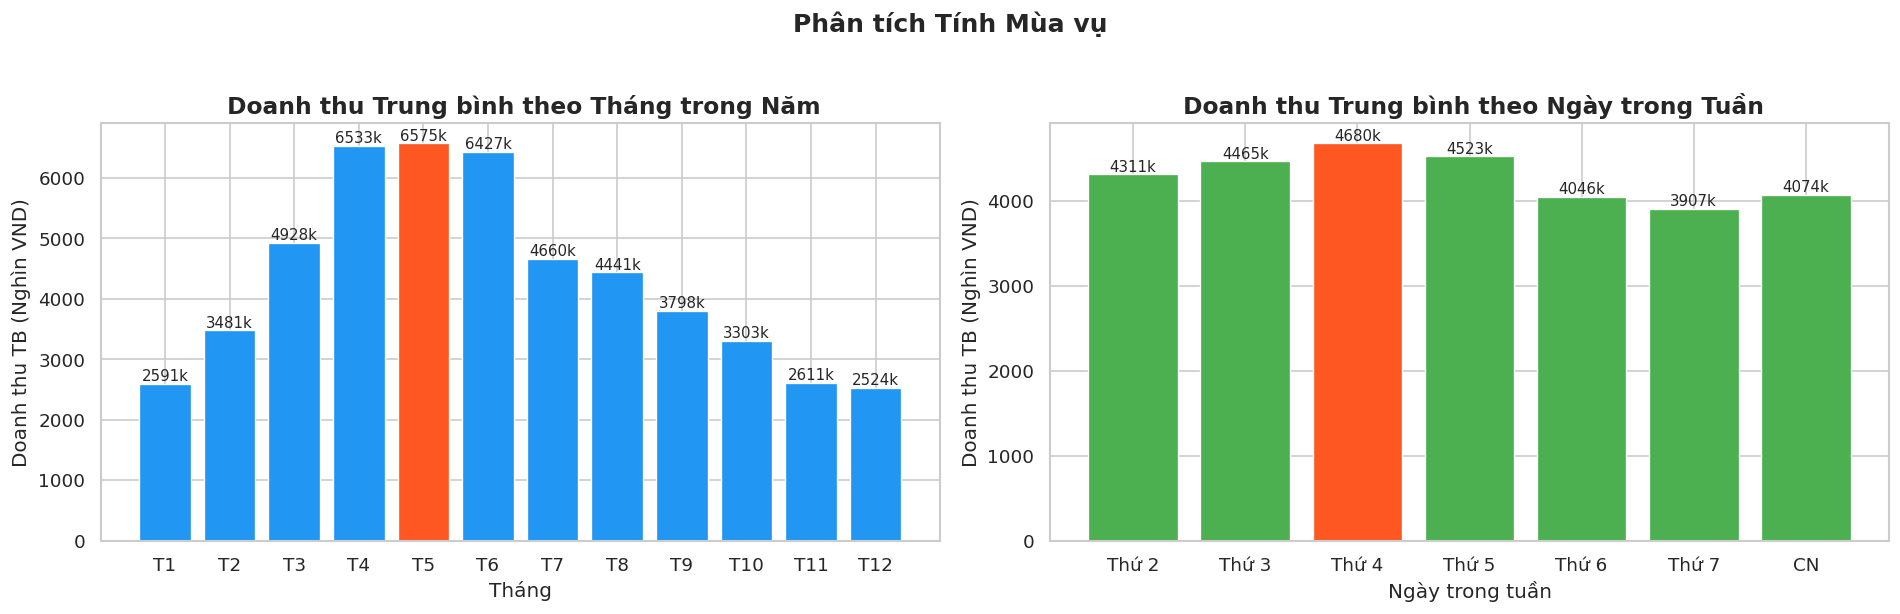


 Peak month: Tháng 5 (T5) — TB 6575.4k VND/ngày
 Peak day  : Thứ 4 — TB 4680.1k VND/ngày


In [5]:
MONTH_NAMES = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
DOW_NAMES   = ['Thứ 2','Thứ 3','Thứ 4','Thứ 5','Thứ 6','Thứ 7','CN']

monthly_avg = sales.groupby('month')['Revenue'].mean()
dow_avg     = sales.groupby('dow')['Revenue'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Seasonality by month
colors_m = ['#FF5722' if v == monthly_avg.max() else '#2196F3' for v in monthly_avg]
axes[0].bar(MONTH_NAMES, monthly_avg/1e3, color=colors_m, edgecolor='white', linewidth=0.8)
axes[0].set_title('️ Doanh thu Trung bình theo Tháng trong Năm', fontweight='bold')
axes[0].set_ylabel('Doanh thu TB (Nghìn VND)')
axes[0].set_xlabel('Tháng')
for i, v in enumerate(monthly_avg):
    axes[0].text(i, v/1e3 + 0.5, f'{v/1e3:.0f}k', ha='center', va='bottom', fontsize=9)

# Seasonality by day of week
colors_d = ['#FF5722' if v == dow_avg.max() else '#4CAF50' for v in dow_avg]
axes[1].bar(DOW_NAMES, dow_avg/1e3, color=colors_d, edgecolor='white', linewidth=0.8)
axes[1].set_title(' Doanh thu Trung bình theo Ngày trong Tuần', fontweight='bold')
axes[1].set_ylabel('Doanh thu TB (Nghìn VND)')
axes[1].set_xlabel('Ngày trong tuần')
for i, v in enumerate(dow_avg):
    axes[1].text(i, v/1e3 + 0.5, f'{v/1e3:.0f}k', ha='center', va='bottom', fontsize=9)

plt.suptitle('Phân tích Tính Mùa vụ', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./eda_graph/fig02_seasonality.png', bbox_inches='tight')
plt.show()

peak_month = MONTH_NAMES[monthly_avg.idxmax()-1]
print(f"\n Peak month: Tháng {monthly_avg.idxmax()} ({peak_month}) — TB {monthly_avg.max()/1e3:.1f}k VND/ngày")
print(f" Peak day  : {DOW_NAMES[dow_avg.idxmax()]} — TB {dow_avg.max()/1e3:.1f}k VND/ngày")

### 3.3 Phân tích Sản phẩm & Danh mục

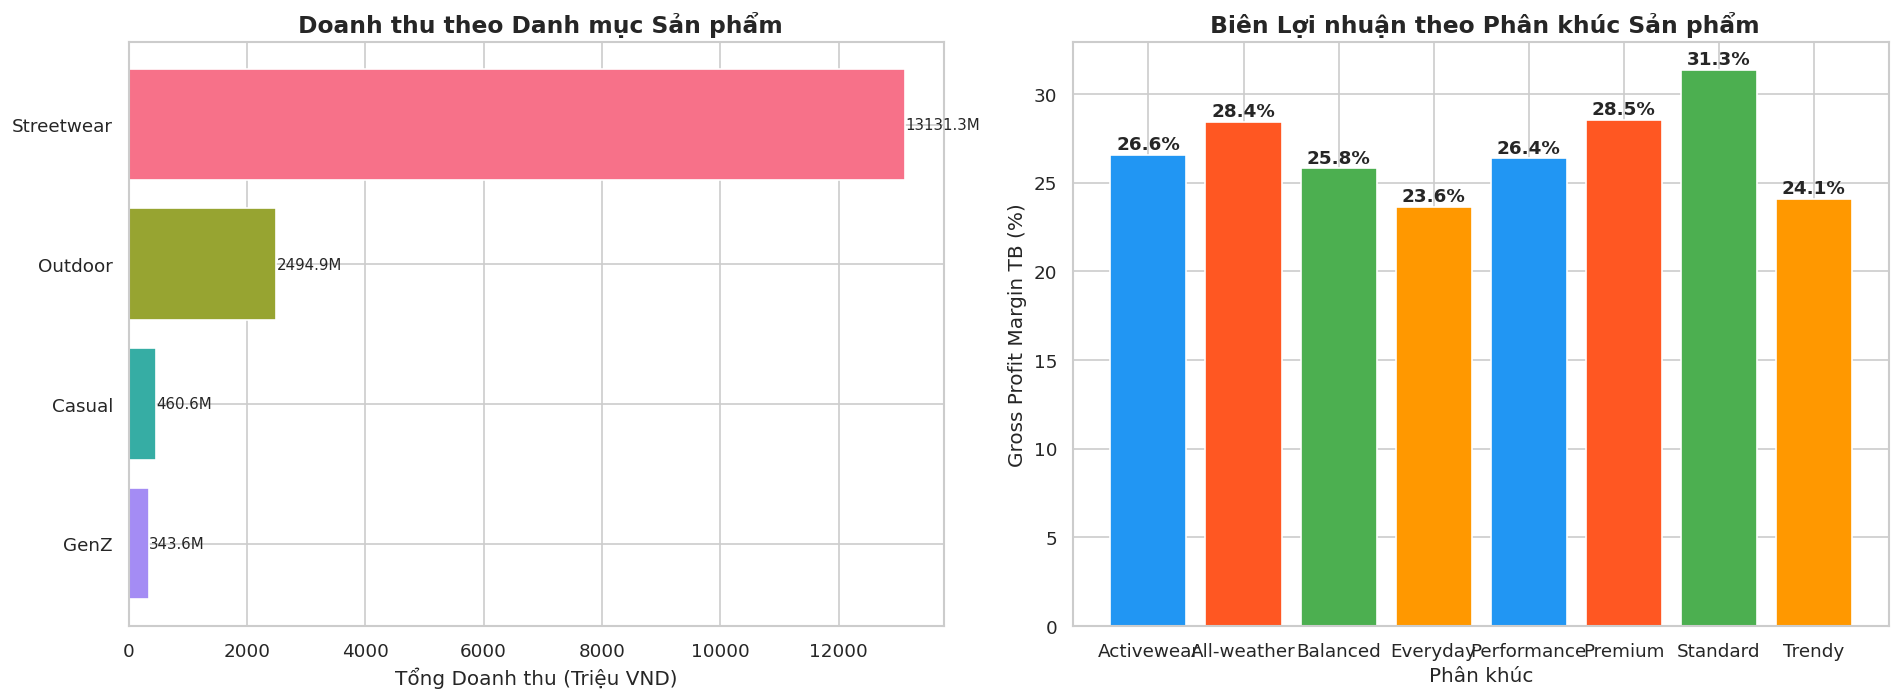

  category     Total_Revenue  Total_Qty  Avg_Price  Num_Orders
Streetwear 13,131,346,352.62    1768826   7,423.69      389543
   Outdoor  2,494,882,754.20    1170000   2,131.73      200454
    Casual    460,648,383.35     107469   4,295.67       23600
      GenZ    343,599,095.36     166848   2,060.45       37054


In [6]:
# Join order_items + products
oi_prod = order_items.merge(products, on='product_id')

# Revenue per category (unit_price * quantity)
oi_prod['line_revenue'] = oi_prod['unit_price'] * oi_prod['quantity']
cat_rev = oi_prod.groupby('category').agg(
    Total_Revenue=('line_revenue','sum'),
    Total_Qty=('quantity','sum'),
    Avg_Price=('unit_price','mean'),
    Num_Orders=('order_id','nunique')
).sort_values('Total_Revenue', ascending=False).reset_index()

seg_margin = products.groupby('segment').apply(
    lambda df: ((df['price'] - df['cogs']) / df['price'] * 100).mean()
).reset_index()
seg_margin.columns = ['segment','avg_margin_%']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Category revenue bar
colors_c = sns.color_palette('husl', len(cat_rev))
bars = axes[0].barh(cat_rev['category'], cat_rev['Total_Revenue']/1e6,
                    color=colors_c, edgecolor='white')
axes[0].set_xlabel('Tổng Doanh thu (Triệu VND)')
axes[0].set_title(' Doanh thu theo Danh mục Sản phẩm', fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, cat_rev['Total_Revenue']):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val/1e6:.1f}M', va='center', fontsize=9)

# Segment gross margin
colors_s = ['#2196F3','#FF5722','#4CAF50','#FF9800']
bars2 = axes[1].bar(seg_margin['segment'], seg_margin['avg_margin_%'],
                    color=colors_s[:len(seg_margin)], edgecolor='white')
axes[1].set_ylabel('Gross Profit Margin TB (%)')
axes[1].set_title(' Biên Lợi nhuận theo Phân khúc Sản phẩm', fontweight='bold')
axes[1].set_xlabel('Phân khúc')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{bar.get_height():.1f}%", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./eda_graph/fig03_product_analysis.png', bbox_inches='tight')
plt.show()
print(cat_rev.to_string(index=False))

### 3.4 Hành vi Khách hàng

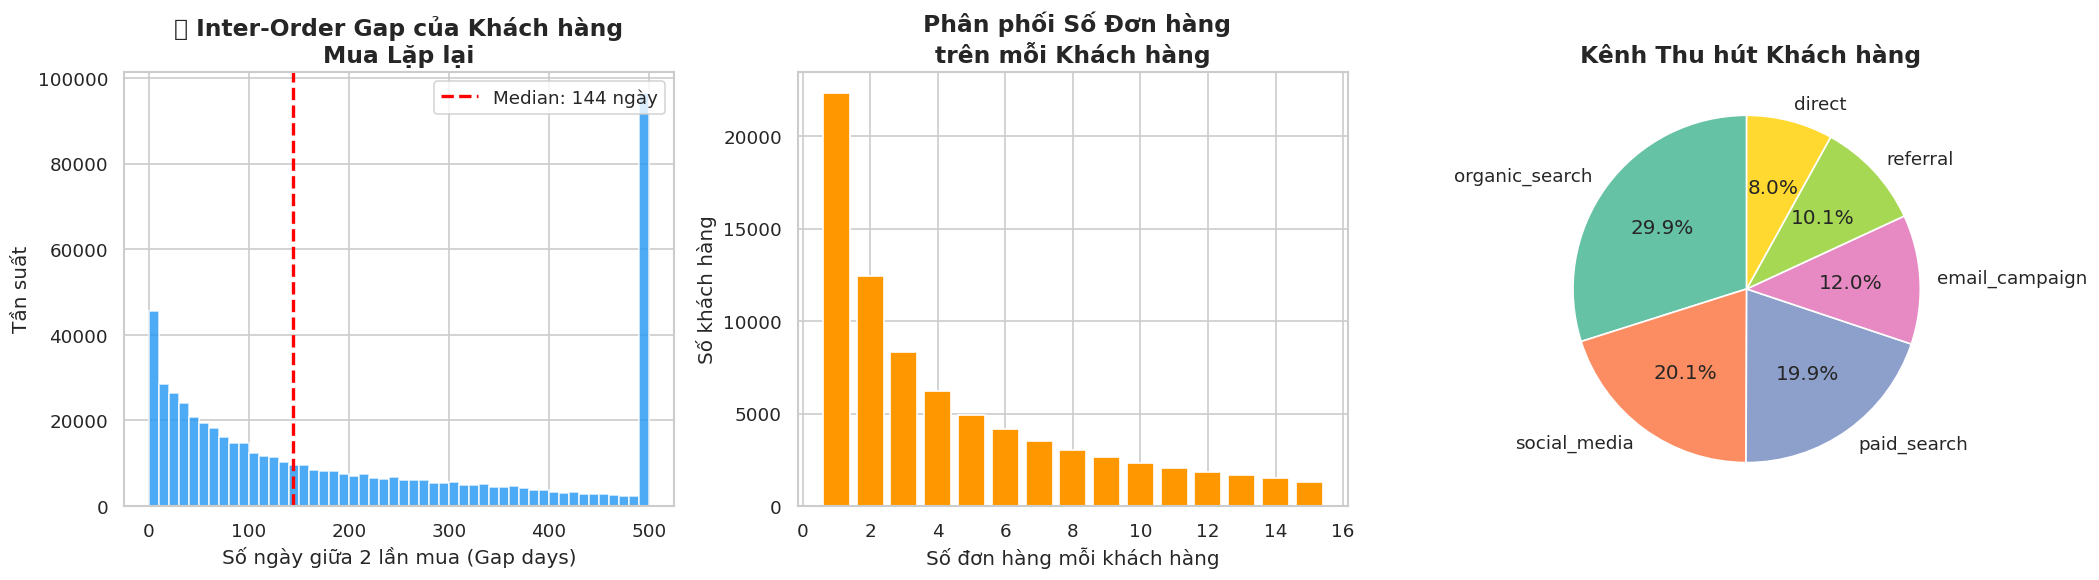


 Median inter-order gap: 144 ngày
 Khách hàng chỉ mua 1 lần: 22,358 (24.8%)


In [7]:
# Số đơn mỗi KH
cust_orders = orders.groupby('customer_id').agg(
    num_orders=('order_id','count'),
    first_order=('order_date','min'),
    last_order=('order_date','max')
).reset_index()
cust_orders['tenure_days'] = (cust_orders['last_order'] - cust_orders['first_order']).dt.days

# Inter-order gap (Q1 answer)
orders_sorted = orders.sort_values(['customer_id','order_date'])
orders_sorted['prev_order'] = orders_sorted.groupby('customer_id')['order_date'].shift(1)
orders_sorted['gap_days'] = (orders_sorted['order_date'] - orders_sorted['prev_order']).dt.days
repeat_gaps = orders_sorted.dropna(subset=['gap_days'])
median_gap = repeat_gaps['gap_days'].median()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Inter-order gap distribution
axes[0].hist(repeat_gaps['gap_days'].clip(0, 500), bins=50,
             color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(median_gap, color='red', linestyle='--', linewidth=2,
                label=f'Median: {median_gap:.0f} ngày')
axes[0].set_xlabel('Số ngày giữa 2 lần mua (Gap days)')
axes[0].set_ylabel('Tần suất')
axes[0].set_title('⏱️ Inter-Order Gap của Khách hàng\nMua Lặp lại', fontweight='bold')
axes[0].legend()

# Orders per customer
order_dist = cust_orders['num_orders'].value_counts().sort_index().head(15)
axes[1].bar(order_dist.index, order_dist.values, color='#FF9800', edgecolor='white')
axes[1].set_xlabel('Số đơn hàng mỗi khách hàng')
axes[1].set_ylabel('Số khách hàng')
axes[1].set_title(' Phân phối Số Đơn hàng\ntrên mỗi Khách hàng', fontweight='bold')

# Acquisition channel
if 'acquisition_channel' in customers.columns:
    acq = customers['acquisition_channel'].value_counts(dropna=False)
    axes[2].pie(acq.values, labels=acq.index, autopct='%1.1f%%',
                colors=sns.color_palette('Set2', len(acq)), startangle=90)
    axes[2].set_title(' Kênh Thu hút Khách hàng', fontweight='bold')

plt.tight_layout()
plt.savefig('./eda_graph/fig04_customer_behavior.png', bbox_inches='tight')
plt.show()

print(f"\n Median inter-order gap: {median_gap:.0f} ngày")
one_time = (cust_orders['num_orders'] == 1).sum()
print(f" Khách hàng chỉ mua 1 lần: {one_time:,} ({one_time/len(cust_orders)*100:.1f}%)")

### 3.5 Web Traffic Snapshot

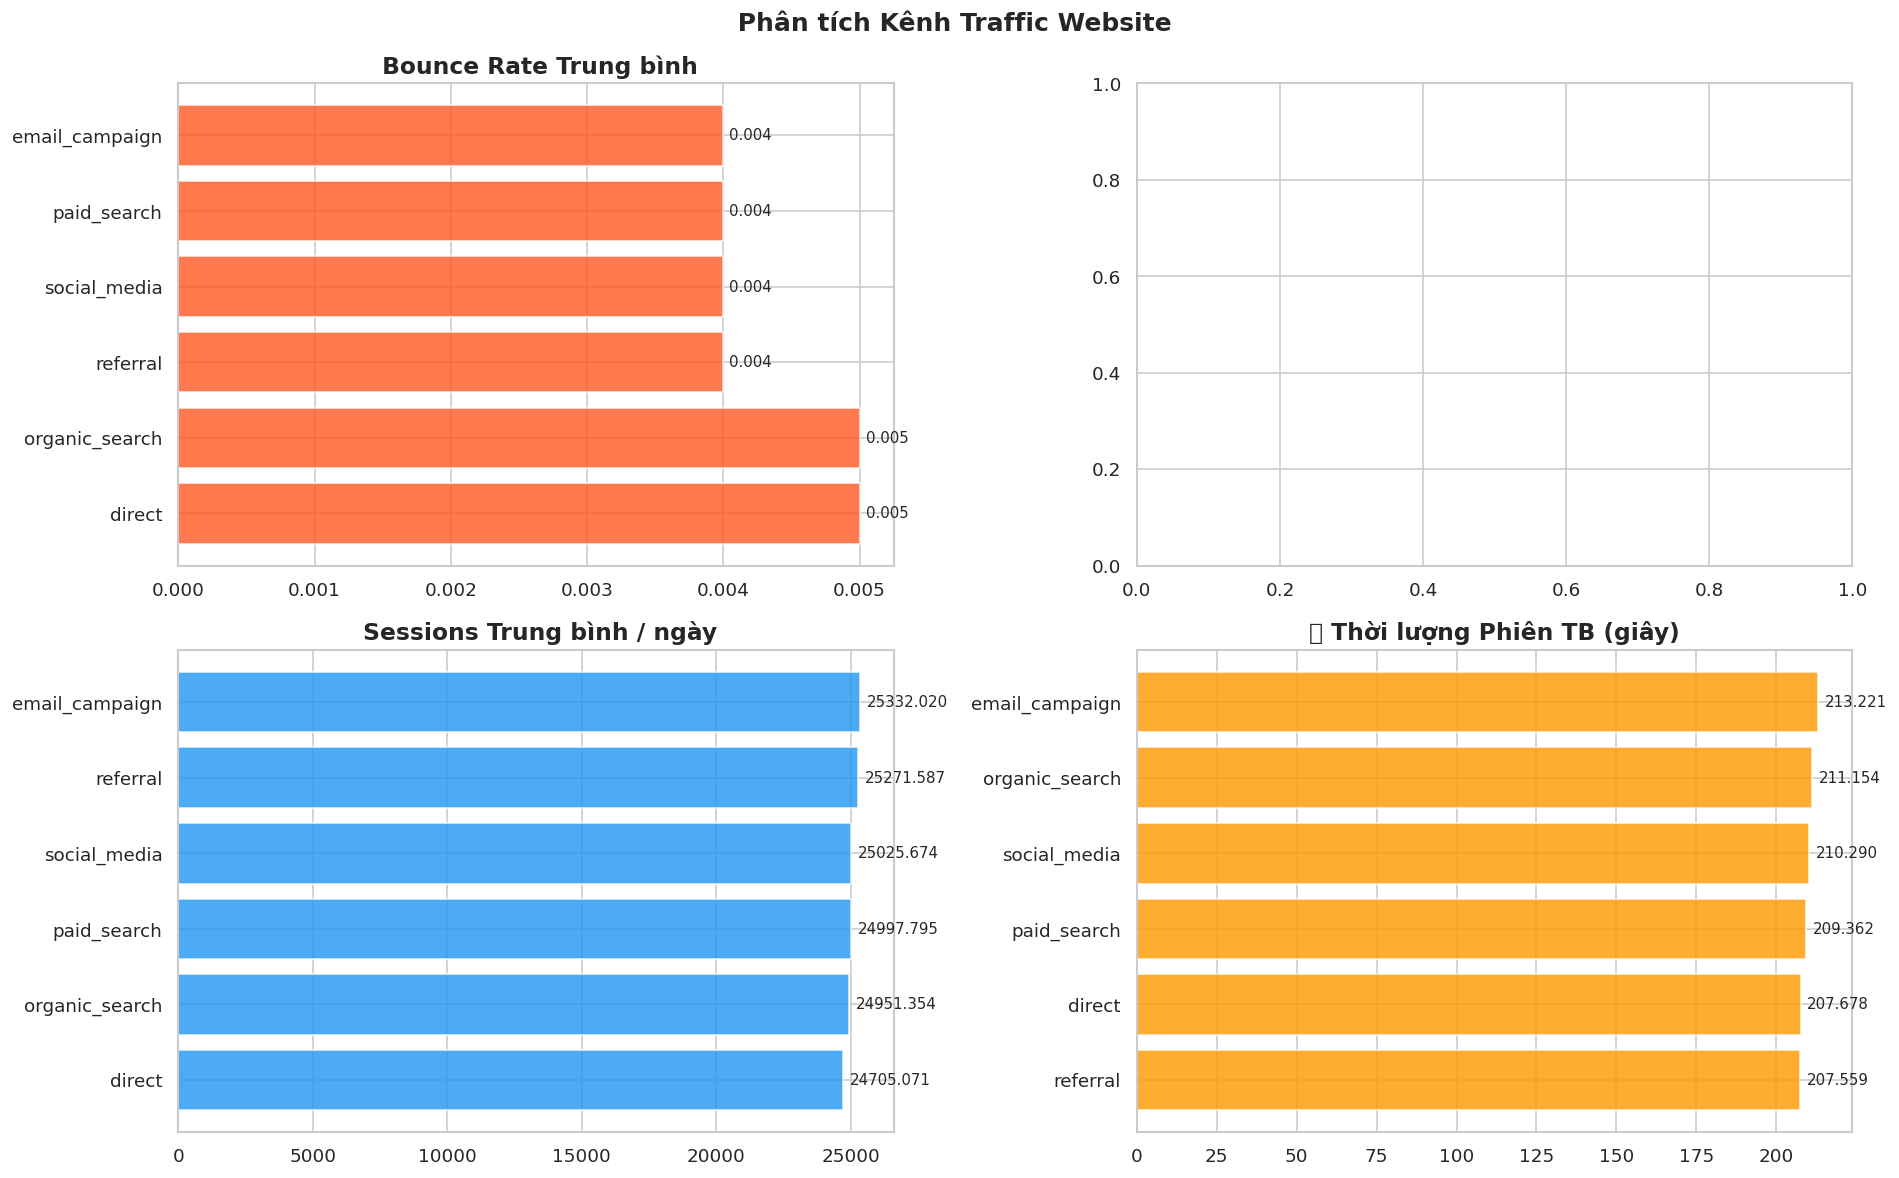


Bảng tóm tắt các nguồn traffic:
traffic_source  Avg_Sessions  Avg_BounceRate  Avg_Duration
email_campaign     25,332.02            0.00        213.22
   paid_search     24,997.79            0.00        209.36
  social_media     25,025.67            0.00        210.29
      referral     25,271.59            0.00        207.56
organic_search     24,951.35            0.01        211.15
        direct     24,705.07            0.01        207.68


In [8]:
# Traffic source summary
traffic_summary = web_traffic.groupby('traffic_source').agg(
    Avg_Sessions=('sessions','mean'),
    Avg_BounceRate=('bounce_rate','mean'),
    Avg_Duration=('avg_session_duration_sec','mean')
).round(3).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = [
    ('Avg_BounceRate', ' Bounce Rate Trung bình', '#FF5722', axes[0,0]),
    ('Avg_Sessions',   ' Sessions Trung bình / ngày', '#2196F3', axes[1,0]),
    ('Avg_Duration',   '⏳ Thời lượng Phiên TB (giây)', '#FF9800', axes[1,1]),
]

for col, title, color, ax in metrics:
    sorted_df = traffic_summary.sort_values(col, ascending=(col == 'Avg_BounceRate'))
    bars = ax.barh(sorted_df['traffic_source'], sorted_df[col], color=color, alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    for bar in bars:
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=9)

plt.suptitle(' Phân tích Kênh Traffic Website', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./eda_graph/fig05_web_traffic.png', bbox_inches='tight')
plt.show()

print("\nBảng tóm tắt các nguồn traffic:")
print(traffic_summary.sort_values('Avg_BounceRate').to_string(index=False))

---
##  DIAGNOSTIC — Tại sao nó xảy ra?

### 4.1 Phân tích Khuyến mãi vs Doanh thu

 Tỷ lệ dòng có áp dụng khuyến mãi: 38.7%


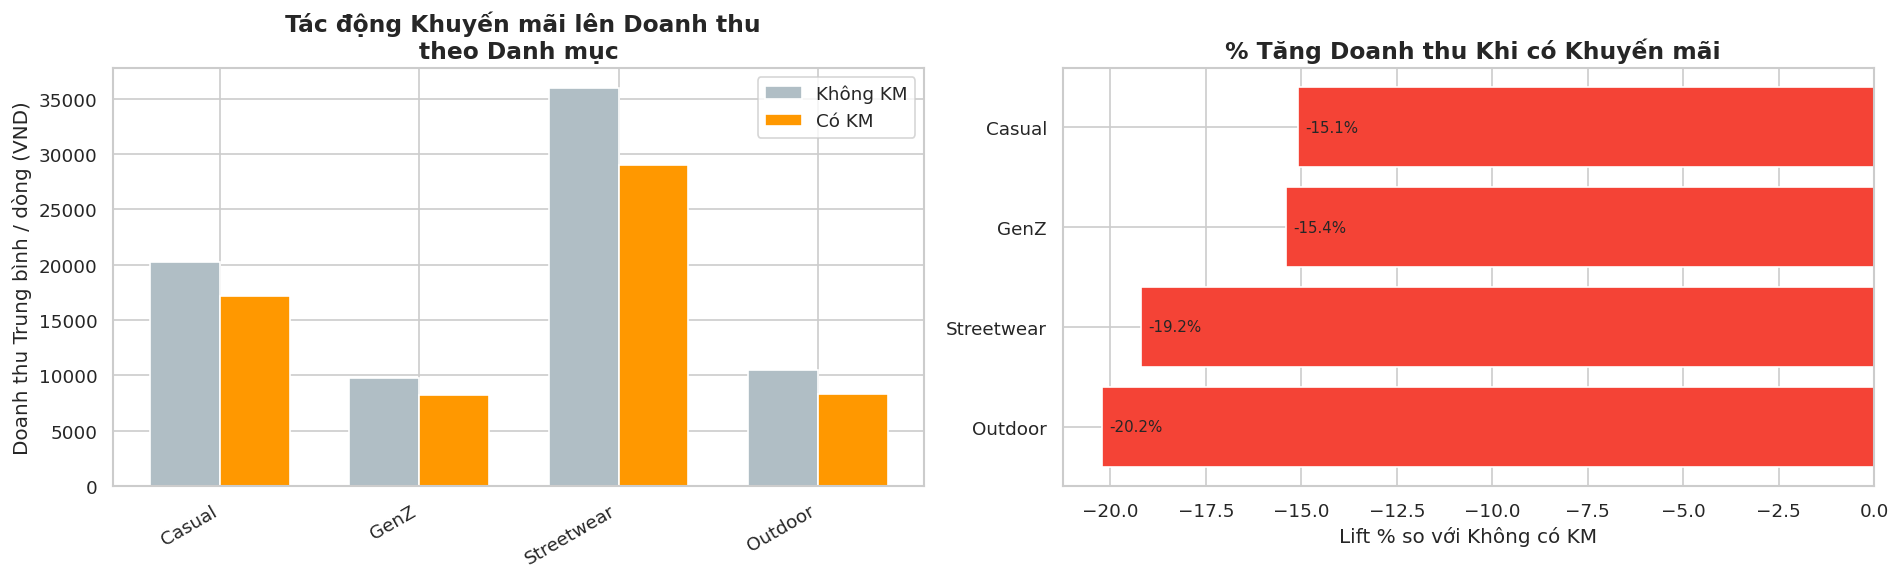

In [9]:
# Tỷ lệ đơn có promo (Q5)
promo_rate = order_items['promo_id'].notna().mean() * 100
print(f" Tỷ lệ dòng có áp dụng khuyến mãi: {promo_rate:.1f}%")

# Discount impact per category
oi_prod['has_promo'] = oi_prod['promo_id'].notna()
oi_prod['revenue_before_discount'] = oi_prod['unit_price'] * oi_prod['quantity'] + oi_prod['discount_amount']
oi_prod['discount_pct'] = oi_prod['discount_amount'] / oi_prod['revenue_before_discount'] * 100

promo_by_cat = oi_prod.groupby(['category','has_promo']).agg(
    avg_revenue=('line_revenue','mean'),
    count=('order_id','count')
).reset_index()

# Pivot
promo_pivot = promo_by_cat.pivot(index='category', columns='has_promo', values='avg_revenue')
promo_pivot.columns = ['No Promo','With Promo']
promo_pivot['Lift%'] = (promo_pivot['With Promo'] - promo_pivot['No Promo']) / promo_pivot['No Promo'] * 100
promo_pivot = promo_pivot.sort_values('Lift%', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grouped bar
x = range(len(promo_pivot))
w = 0.35
axes[0].bar([i-w/2 for i in x], promo_pivot['No Promo'], w, label='Không KM', color='#B0BEC5')
axes[0].bar([i+w/2 for i in x], promo_pivot['With Promo'], w, label='Có KM', color='#FF9800')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(promo_pivot.index, rotation=30, ha='right')
axes[0].set_ylabel('Doanh thu Trung bình / dòng (VND)')
axes[0].set_title(' Tác động Khuyến mãi lên Doanh thu\ntheo Danh mục', fontweight='bold')
axes[0].legend()

# Lift %
colors_lift = ['#4CAF50' if v > 0 else '#F44336' for v in promo_pivot['Lift%']]
axes[1].barh(promo_pivot.index, promo_pivot['Lift%'], color=colors_lift, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Lift % so với Không có KM')
axes[1].set_title(' % Tăng Doanh thu Khi có Khuyến mãi', fontweight='bold')
axes[1].invert_yaxis()
for i, (idx, row) in enumerate(promo_pivot.iterrows()):
    axes[1].text(row['Lift%'] + 0.2, i, f"{row['Lift%']:+.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('./eda_graph/fig06_promo_impact.png', bbox_inches='tight')
plt.show()

### 4.2 Phân tích Trả hàng (Returns)

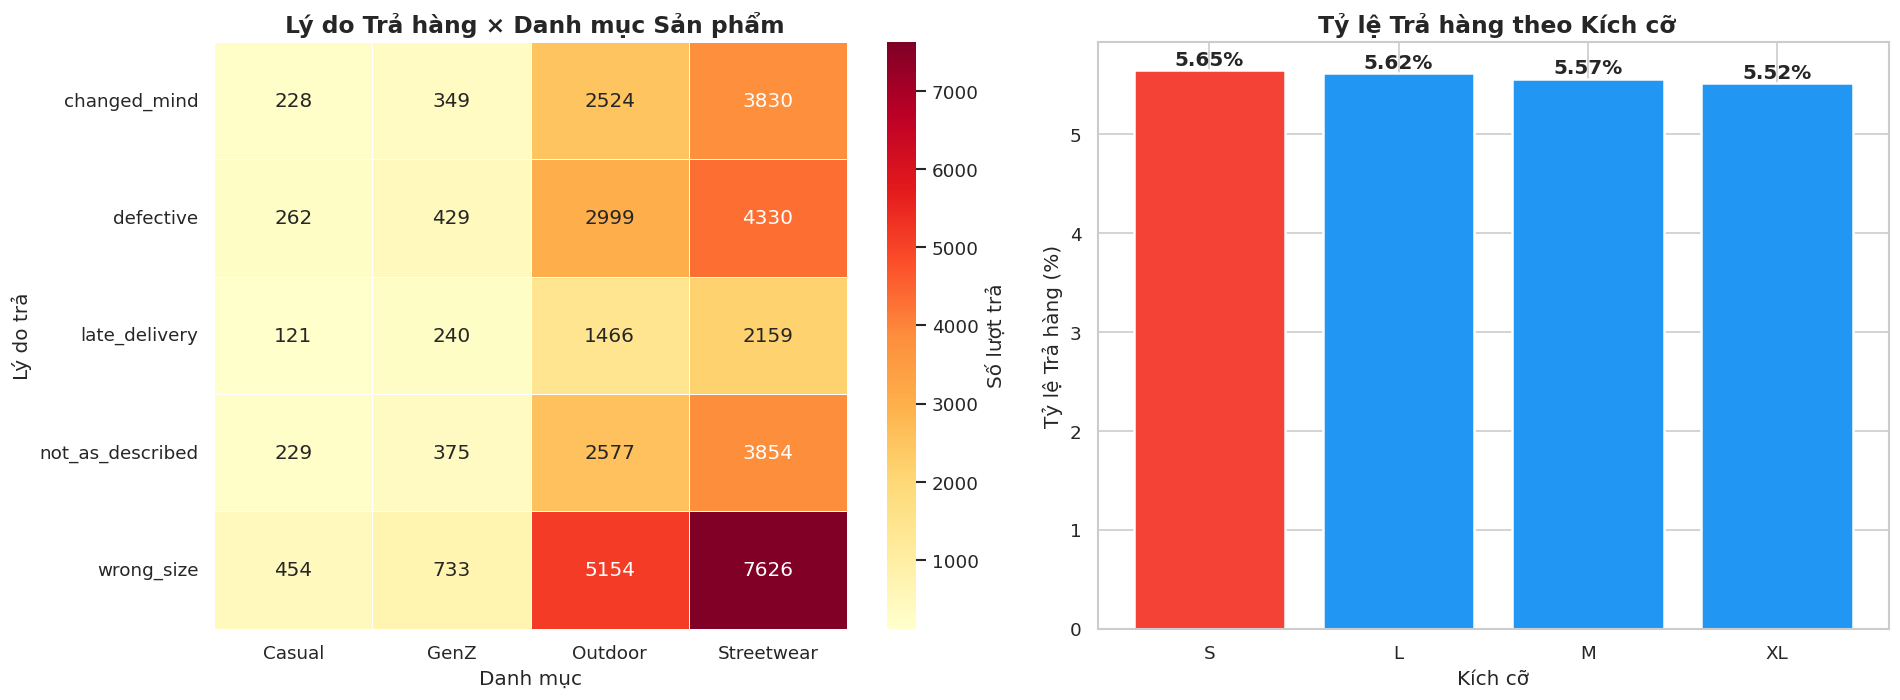


 Tỷ lệ trả hàng theo kích cỡ:
size  n_ordered  n_returned  return_rate%
   S     172042        9723          5.65
   L     173174        9741          5.62
   M     176428        9820          5.57
  XL     193025       10655          5.52


In [10]:
# Join returns + products
ret_prod = returns.merge(products[['product_id','category','segment','size']], on='product_id')

# Return reason by category
reason_cat = ret_prod.groupby(['category','return_reason'])['return_id'].count().reset_index()
reason_cat.columns = ['category','reason','count']

# Return rate by size (Q9)
oi_size = oi_prod.groupby('size')['order_id'].count().reset_index()
oi_size.columns = ['size','n_ordered']
ret_size = ret_prod.groupby('size')['return_id'].count().reset_index()
ret_size.columns = ['size','n_returned']
size_rate = oi_size.merge(ret_size, on='size')
size_rate['return_rate%'] = size_rate['n_returned'] / size_rate['n_ordered'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap reason × category
pivot_rc = reason_cat.pivot(index='reason', columns='category', values='count').fillna(0)
sns.heatmap(pivot_rc, ax=axes[0], cmap='YlOrRd', fmt='.0f', annot=True,
            linewidths=0.5, cbar_kws={'label': 'Số lượt trả'})
axes[0].set_title(' Lý do Trả hàng × Danh mục Sản phẩm', fontweight='bold')
axes[0].set_xlabel('Danh mục')
axes[0].set_ylabel('Lý do trả')

# Return rate by size
size_rate_sorted = size_rate.sort_values('return_rate%', ascending=False)
colors_sz = ['#F44336' if v == size_rate['return_rate%'].max() else '#2196F3'
             for v in size_rate_sorted['return_rate%']]
axes[1].bar(size_rate_sorted['size'], size_rate_sorted['return_rate%'],
            color=colors_sz, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Kích cỡ')
axes[1].set_ylabel('Tỷ lệ Trả hàng (%)')
axes[1].set_title(' Tỷ lệ Trả hàng theo Kích cỡ', fontweight='bold')
for i, row in size_rate_sorted.iterrows():
    axes[1].text(list(size_rate_sorted['size']).index(row['size']),
                 row['return_rate%'] + 0.05, f"{row['return_rate%']:.2f}%",
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('./eda_graph/fig07_returns_analysis.png', bbox_inches='tight')
plt.show()

print("\n Tỷ lệ trả hàng theo kích cỡ:")
print(size_rate_sorted[['size','n_ordered','n_returned','return_rate%']].to_string(index=False))

### 4.3 Cohort Analysis — Giữ chân Khách hàng

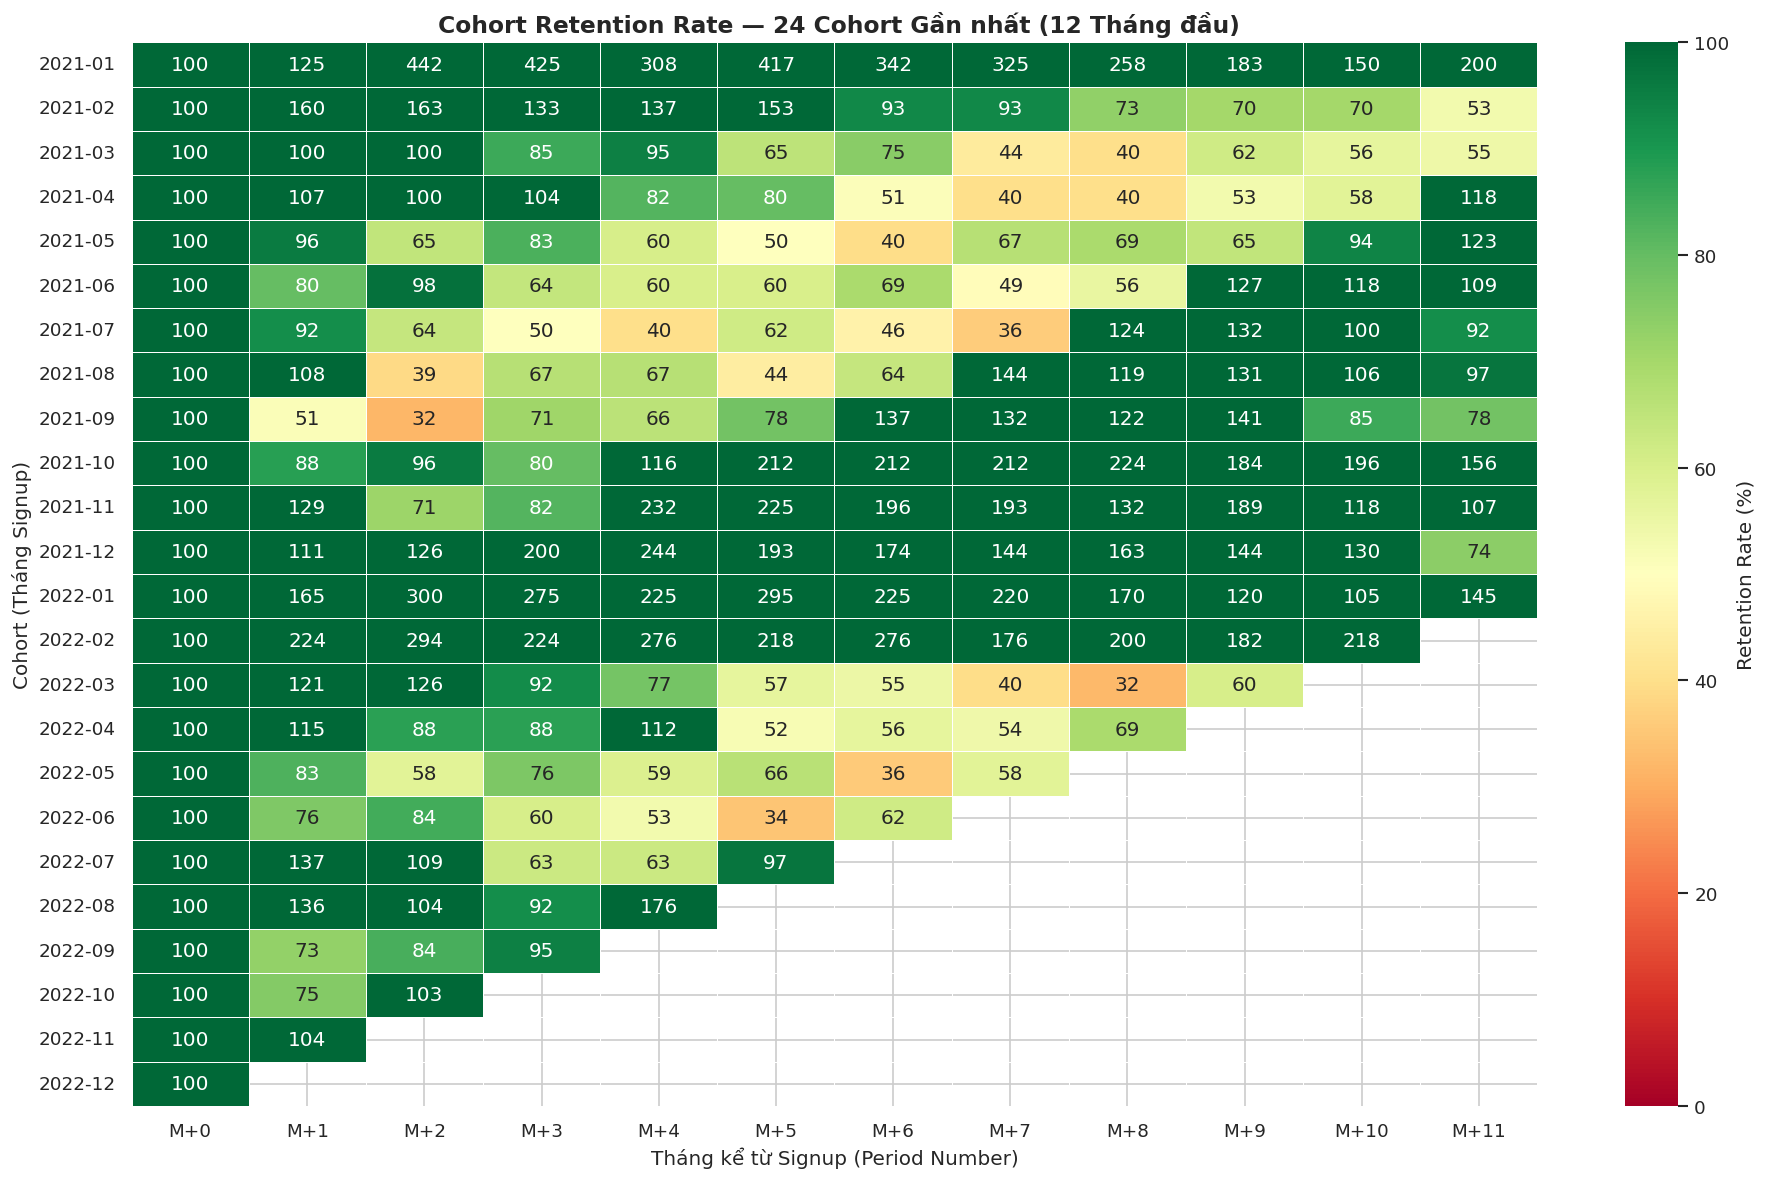


 Tỷ lệ giữ chân TB tháng 1 (M+1): 108.1%
 Tỷ lệ giữ chân TB tháng 3 (M+3): 115.3%


In [11]:
# Cohort: tháng đăng ký đầu tiên
orders_cust = orders.merge(customers[['customer_id','signup_date']], on='customer_id')
orders_cust['cohort_month'] = orders_cust['signup_date'].dt.to_period('M')
orders_cust['order_period']  = orders_cust['order_date'].dt.to_period('M')
orders_cust['period_number'] = (
    orders_cust['order_period'].apply(lambda x: x.ordinal) -
    orders_cust['cohort_month'].apply(lambda x: x.ordinal)
)

cohort_data = orders_cust[orders_cust['period_number'] >= 0].groupby(
    ['cohort_month','period_number'])['customer_id'].nunique().reset_index()

cohort_pivot = cohort_data.pivot_table(
    index='cohort_month', columns='period_number', values='customer_id'
)
# Retention rate
retention = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100

# Plot first 12 months only
retention_12 = retention.iloc[:, :12]

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(retention_12.tail(24),  # show last 24 cohorts
            ax=ax, cmap='RdYlGn', fmt='.0f', annot=True,
            linewidths=0.3, vmin=0, vmax=100,
            cbar_kws={'label': 'Retention Rate (%)'})
ax.set_title(' Cohort Retention Rate — 24 Cohort Gần nhất (12 Tháng đầu)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Tháng kể từ Signup (Period Number)')
ax.set_ylabel('Cohort (Tháng Signup)')
ax.set_xticklabels([f'M+{i}' for i in range(12)])
plt.tight_layout()
plt.savefig('./eda_graph/fig08_cohort_retention.png', bbox_inches='tight')
plt.show()

avg_m1_retention = retention[1].mean()
avg_m3_retention = retention[3].mean() if 3 in retention.columns else None
print(f"\n Tỷ lệ giữ chân TB tháng 1 (M+1): {avg_m1_retention:.1f}%")
if avg_m3_retention:
    print(f" Tỷ lệ giữ chân TB tháng 3 (M+3): {avg_m3_retention:.1f}%")

### 4.4 RFM Segmentation

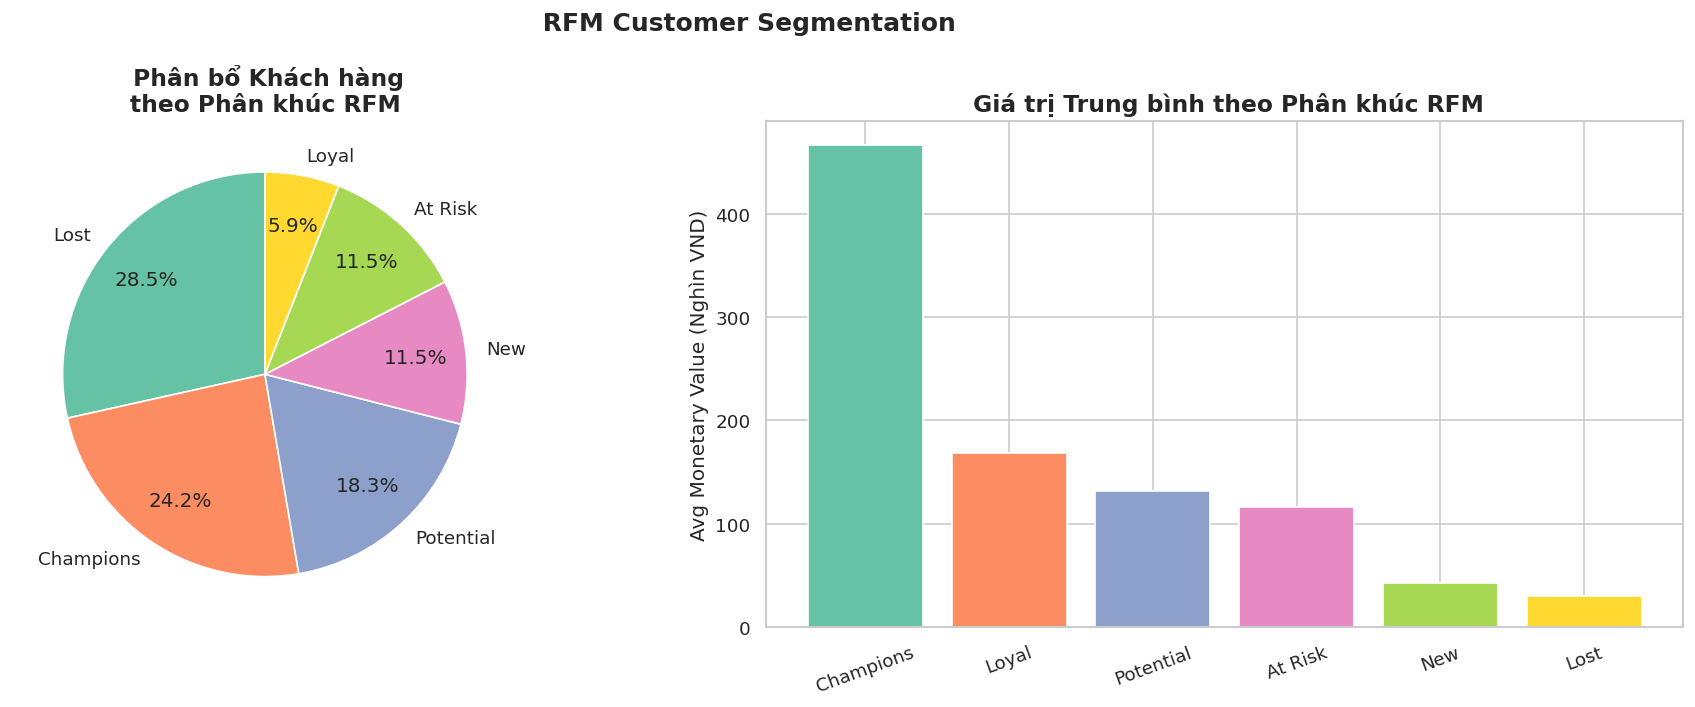


RFM Segment Summary:
           Count  Avg_Recency  Avg_Frequency  Avg_Monetary
segment                                                   
At Risk    10392     1,924.70           5.20    116,370.90
Champions  21838       290.60          18.70    465,937.60
Lost       25705     2,513.30           1.30     30,082.40
Loyal       5360       400.10           7.90    168,242.90
New        10394       724.10           1.60     42,517.90
Potential  16557       765.40           5.60    131,631.20


In [12]:
snapshot_date = orders['order_date'].max() + pd.Timedelta(days=1)

# Merge order_items + payments để lấy payment_value
orders_val = orders.merge(payments[['order_id','payment_value']], on='order_id', how='left')

rfm = orders_val.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id','count'),
    Monetary=('payment_value','sum')
).reset_index()

# Score
rfm['R_score'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def rfm_segment(row):
    if row['RFM_score'] >= 13:
        return 'Champions'
    elif row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Loyal'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Potential'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Lost'
    else:
        return 'New'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

seg_summary = rfm.groupby('segment').agg(
    Count=('customer_id','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean')
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seg_count = rfm['segment'].value_counts()
axes[0].pie(seg_count, labels=seg_count.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(seg_count)),
            startangle=90, pctdistance=0.75)
axes[0].set_title(' Phân bổ Khách hàng\ntheo Phân khúc RFM', fontweight='bold')

seg_monetary = rfm.groupby('segment')['Monetary'].mean().sort_values(ascending=False)
axes[1].bar(seg_monetary.index, seg_monetary/1e3,
            color=sns.color_palette('Set2', len(seg_monetary)))
axes[1].set_ylabel('Avg Monetary Value (Nghìn VND)')
axes[1].set_title(' Giá trị Trung bình theo Phân khúc RFM', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle(' RFM Customer Segmentation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./eda_graph/fig09_rfm.png', bbox_inches='tight')
plt.show()

print("\nRFM Segment Summary:")
print(seg_summary)

---
##  PREDICTIVE — Điều gì có thể xảy ra tiếp theo?

### 5.1 Xu hướng và Decomposition

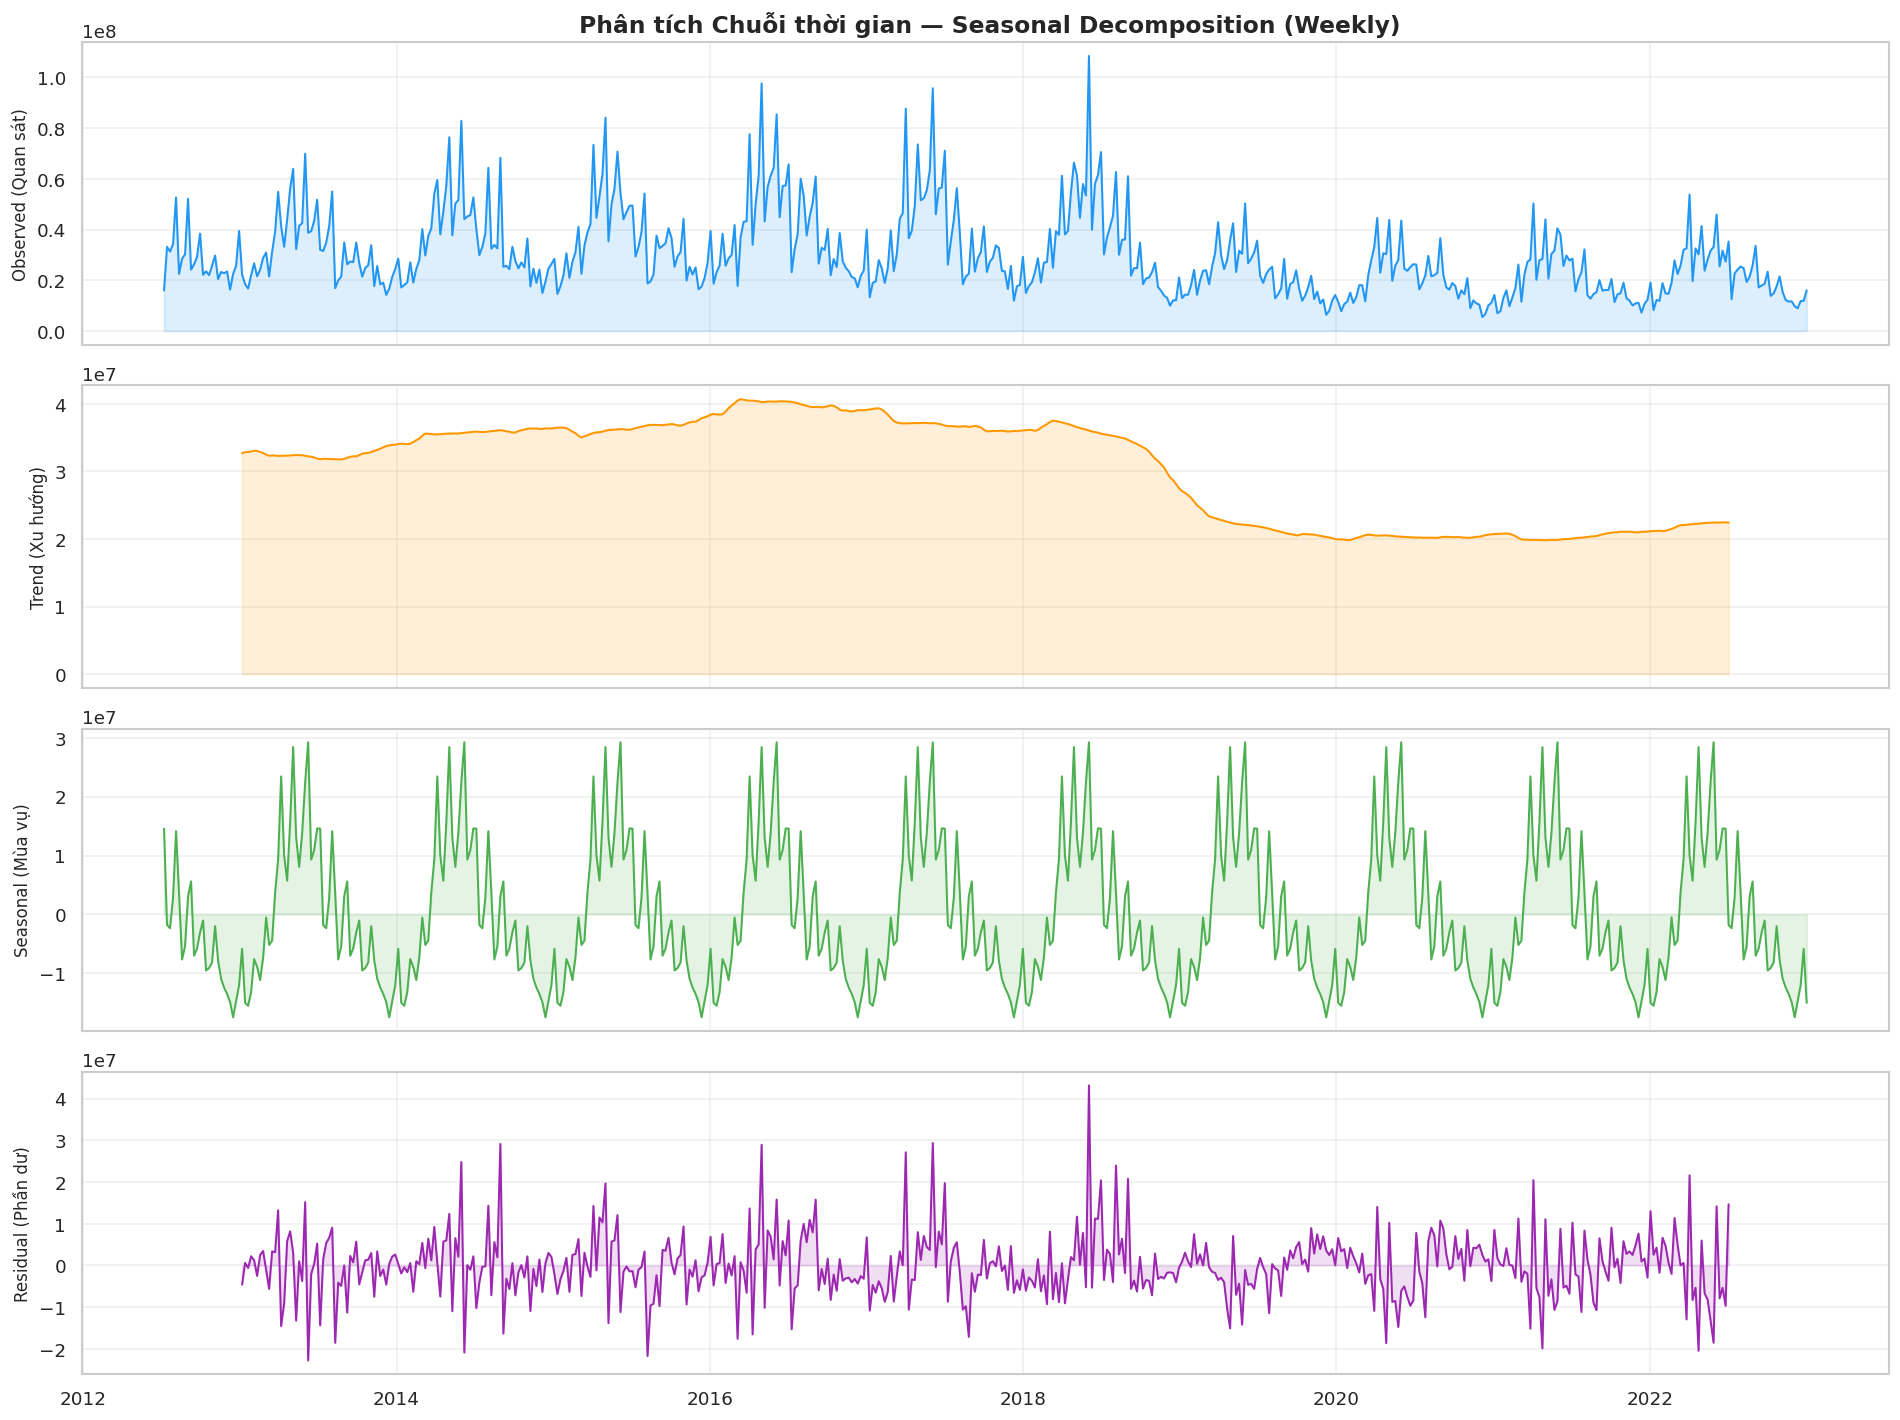

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Daily revenue
daily_rev = sales.set_index('Date')['Revenue'].resample('D').sum().fillna(0)

# Decompose on weekly resampled
weekly_rev = sales.resample('W', on='Date')['Revenue'].sum()
decomp = seasonal_decompose(weekly_rev.dropna(), model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
components = [
    (decomp.observed,  'Observed (Quan sát)',  '#2196F3'),
    (decomp.trend,     'Trend (Xu hướng)',     '#FF9800'),
    (decomp.seasonal,  'Seasonal (Mùa vụ)',    '#4CAF50'),
    (decomp.resid,     'Residual (Phần dư)',   '#9C27B0'),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=1.2)
    ax.fill_between(data.index, data, alpha=0.15, color=color)
    ax.set_ylabel(title, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title(' Phân tích Chuỗi thời gian — Seasonal Decomposition (Weekly)',
                  fontweight='bold', fontsize=14)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('./eda_graph/fig10_decomposition.png', bbox_inches='tight')
plt.show()

### 5.2 Web Traffic & Revenue Correlation (Leading Indicator)

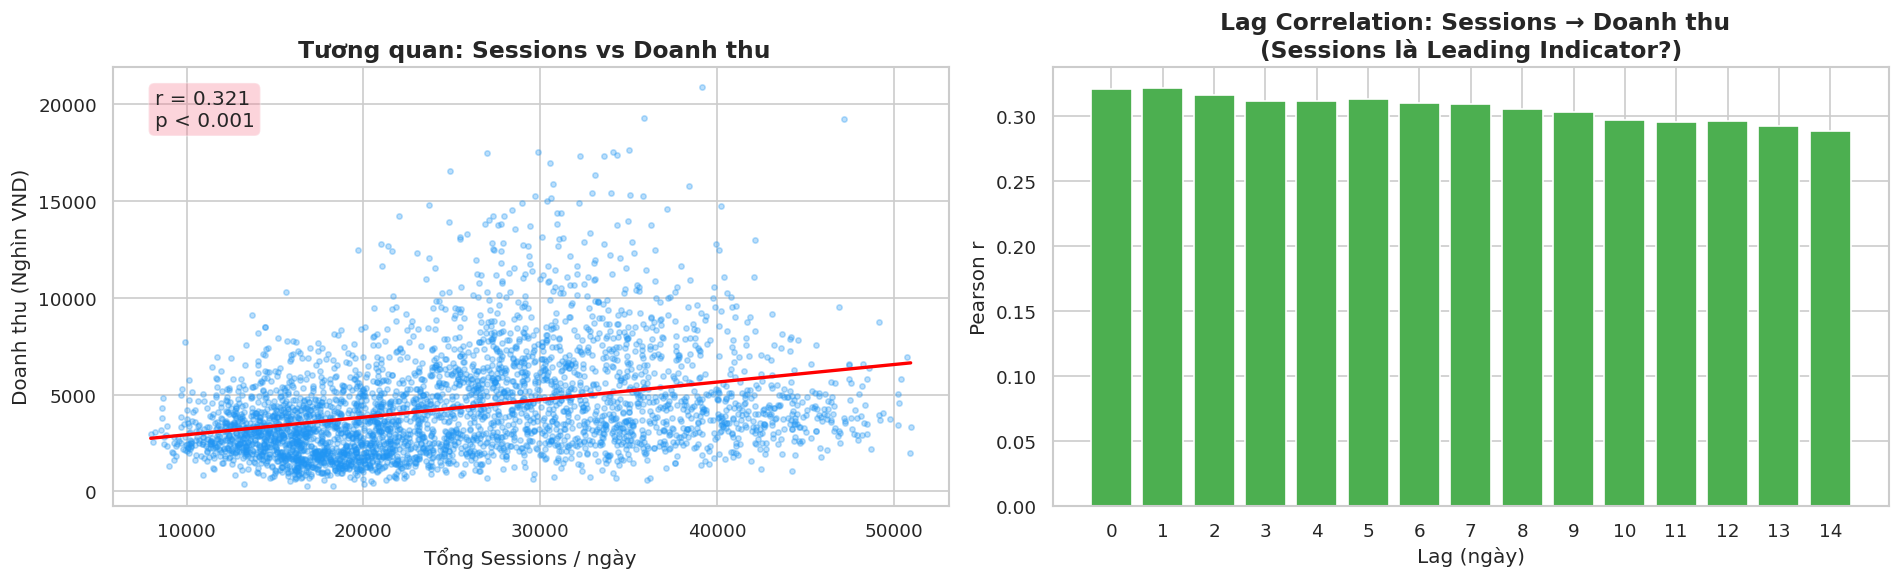


 Lag tốt nhất: 1 ngày (r = 0.322)
→ Web traffic có thể được dùng như leading indicator trong mô hình dự báo!


In [14]:
# Merge sales với web_traffic theo ngày
merged_wt = sales[['Date','Revenue']].merge(
    web_traffic.groupby('date').agg(
        sessions=('sessions','sum'),
        bounce_rate=('bounce_rate','mean')
    ).reset_index().rename(columns={'date':'Date'}),
    on='Date', how='inner'
)

# Lag correlation — sessions vs Revenue
lag_corrs = {}
for lag in range(0, 15):
    corr, _ = pearsonr(
        merged_wt['sessions'].shift(lag).dropna(),
        merged_wt['Revenue'].iloc[lag:]
    )
    lag_corrs[lag] = corr

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter revenue vs sessions
axes[0].scatter(merged_wt['sessions'], merged_wt['Revenue']/1e3,
                alpha=0.3, color='#2196F3', s=10)
m, b = np.polyfit(merged_wt['sessions'], merged_wt['Revenue']/1e3, 1)
x_line = np.linspace(merged_wt['sessions'].min(), merged_wt['sessions'].max(), 100)
axes[0].plot(x_line, m*x_line + b, 'r-', linewidth=2)
axes[0].set_xlabel('Tổng Sessions / ngày')
axes[0].set_ylabel('Doanh thu (Nghìn VND)')
axes[0].set_title(' Tương quan: Sessions vs Doanh thu', fontweight='bold')
r_val, p_val = pearsonr(merged_wt['sessions'], merged_wt['Revenue'])
axes[0].text(0.05, 0.95, f'r = {r_val:.3f}\np < 0.001',
             transform=axes[0].transAxes, va='top', bbox=dict(boxstyle='round', alpha=0.3))

# Lag correlation chart
lags = list(lag_corrs.keys())
corr_vals = list(lag_corrs.values())
colors_lag = ['#4CAF50' if v > 0 else '#F44336' for v in corr_vals]
axes[1].bar(lags, corr_vals, color=colors_lag, edgecolor='white')
axes[1].set_xlabel('Lag (ngày)')
axes[1].set_ylabel('Pearson r')
axes[1].set_title(' Lag Correlation: Sessions → Doanh thu\n(Sessions là Leading Indicator?)',
                  fontweight='bold')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(lags)

plt.tight_layout()
plt.savefig('./eda_graph/fig11_traffic_revenue_corr.png', bbox_inches='tight')
plt.show()

best_lag = max(lag_corrs, key=lag_corrs.get)
print(f"\n Lag tốt nhất: {best_lag} ngày (r = {lag_corrs[best_lag]:.3f})")
print("→ Web traffic có thể được dùng như leading indicator trong mô hình dự báo!")

### 5.3 Inventory Stockout & Doanh thu

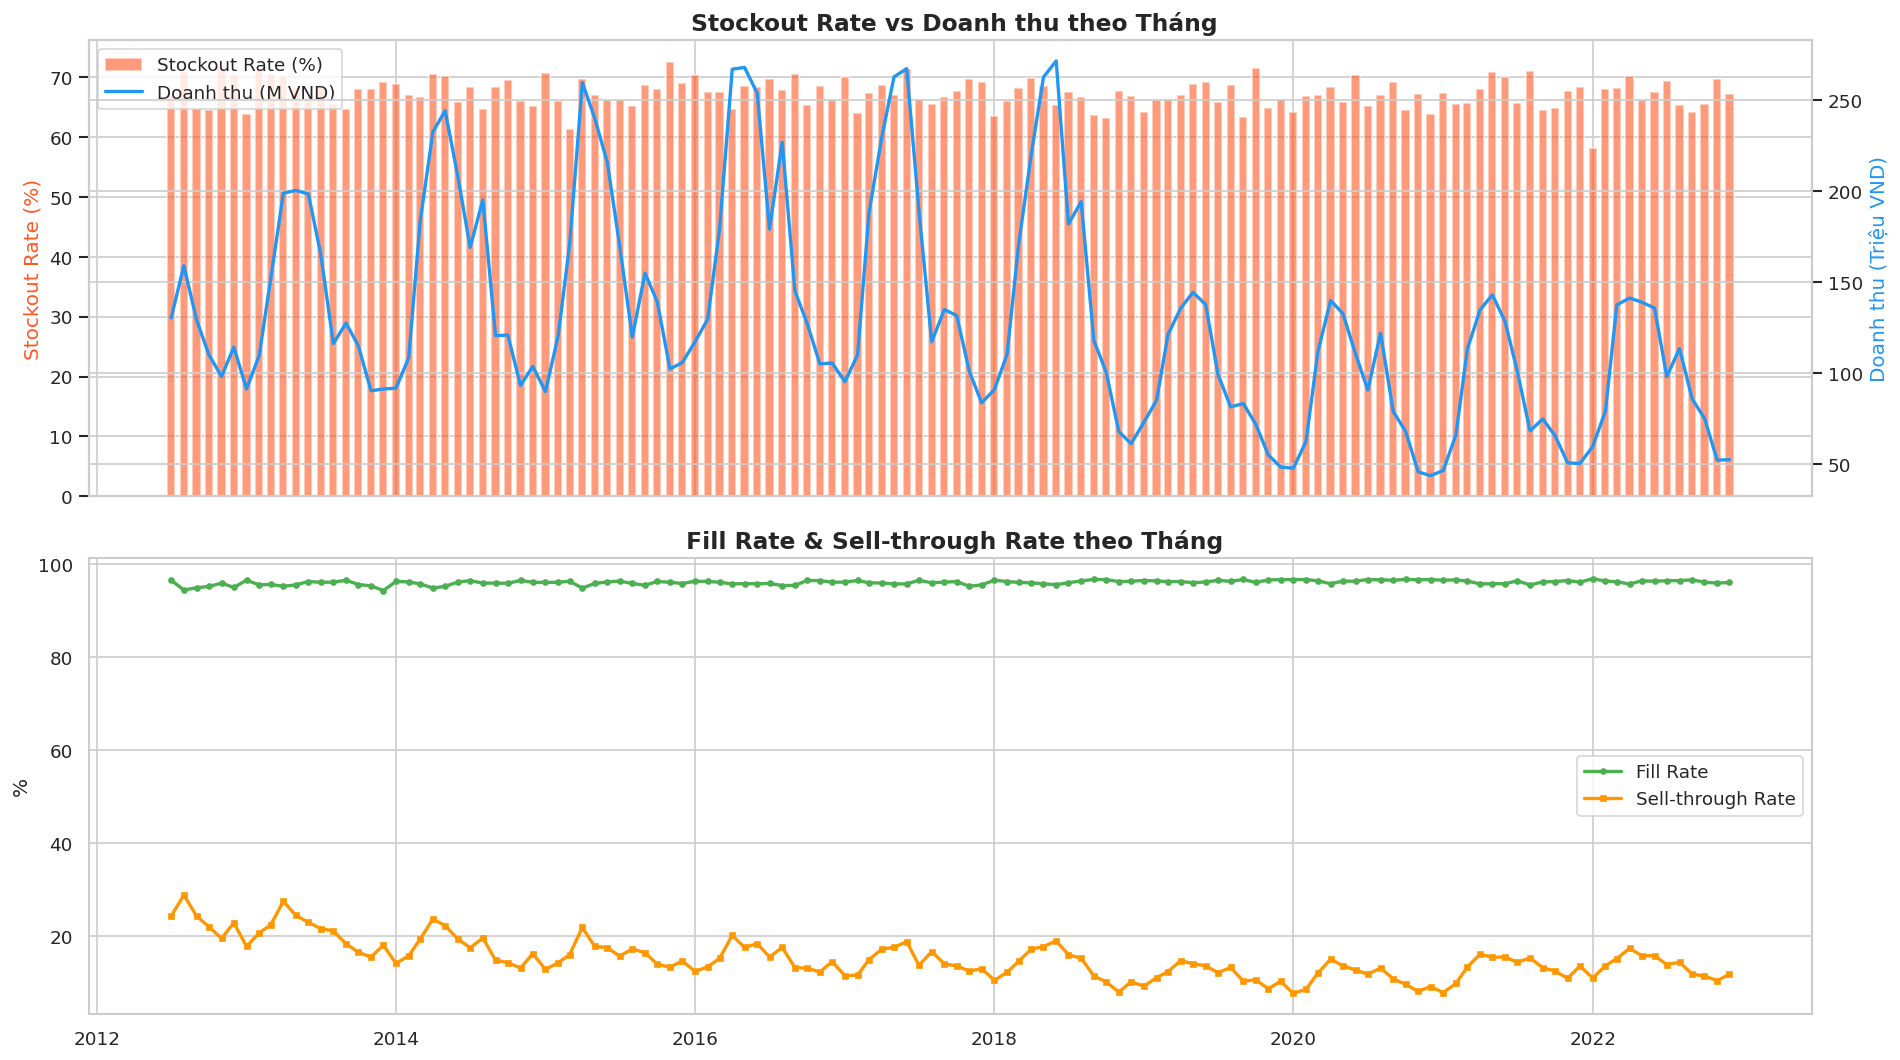


 Tương quan Stockout Rate vs Revenue: r = 0.193
→ Stockout cao → Doanh thu thấp: cần tối ưu hóa quản lý tồn kho


In [15]:
# Monthly stockout rate
stockout_monthly = inventory.groupby(['year','month']).agg(
    stockout_rate=('stockout_flag','mean'),
    avg_fill_rate=('fill_rate','mean'),
    avg_sell_through=('sell_through_rate','mean')
).reset_index()
stockout_monthly['date'] = pd.to_datetime(stockout_monthly[['year','month']].assign(day=1))

monthly_sales = sales.resample('M', on='Date')['Revenue'].sum().reset_index()
monthly_sales.columns = ['date','Revenue']
monthly_sales['date'] = monthly_sales['date'].dt.to_period('M').dt.to_timestamp()

merged_inv = stockout_monthly.merge(monthly_sales, on='date', how='inner')

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.bar(merged_inv['date'], merged_inv['stockout_rate']*100,
        width=20, alpha=0.6, color='#FF5722', label='Stockout Rate (%)')
ax1_twin.plot(merged_inv['date'], merged_inv['Revenue']/1e6,
              color='#2196F3', linewidth=2, label='Doanh thu (M VND)')
ax1.set_ylabel('Stockout Rate (%)', color='#FF5722')
ax1_twin.set_ylabel('Doanh thu (Triệu VND)', color='#2196F3')
ax1.set_title('️ Stockout Rate vs Doanh thu theo Tháng', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

axes[1].plot(merged_inv['date'], merged_inv['avg_fill_rate']*100,
             color='#4CAF50', linewidth=2, marker='o', markersize=3, label='Fill Rate')
axes[1].plot(merged_inv['date'], merged_inv['avg_sell_through']*100,
             color='#FF9800', linewidth=2, marker='s', markersize=3, label='Sell-through Rate')
axes[1].set_ylabel('%')
axes[1].set_title(' Fill Rate & Sell-through Rate theo Tháng', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('./eda_graph/fig12_inventory.png', bbox_inches='tight')
plt.show()

corr_stock, _ = pearsonr(merged_inv['stockout_rate'], merged_inv['Revenue'])
print(f"\n Tương quan Stockout Rate vs Revenue: r = {corr_stock:.3f}")
print("→ Stockout cao → Doanh thu thấp: cần tối ưu hóa quản lý tồn kho")

---
##  PRESCRIPTIVE — Chúng ta nên làm gì?

### 6.1 Ma trận Ưu tiên: Danh mục × Tăng trưởng × Biên lợi nhuận

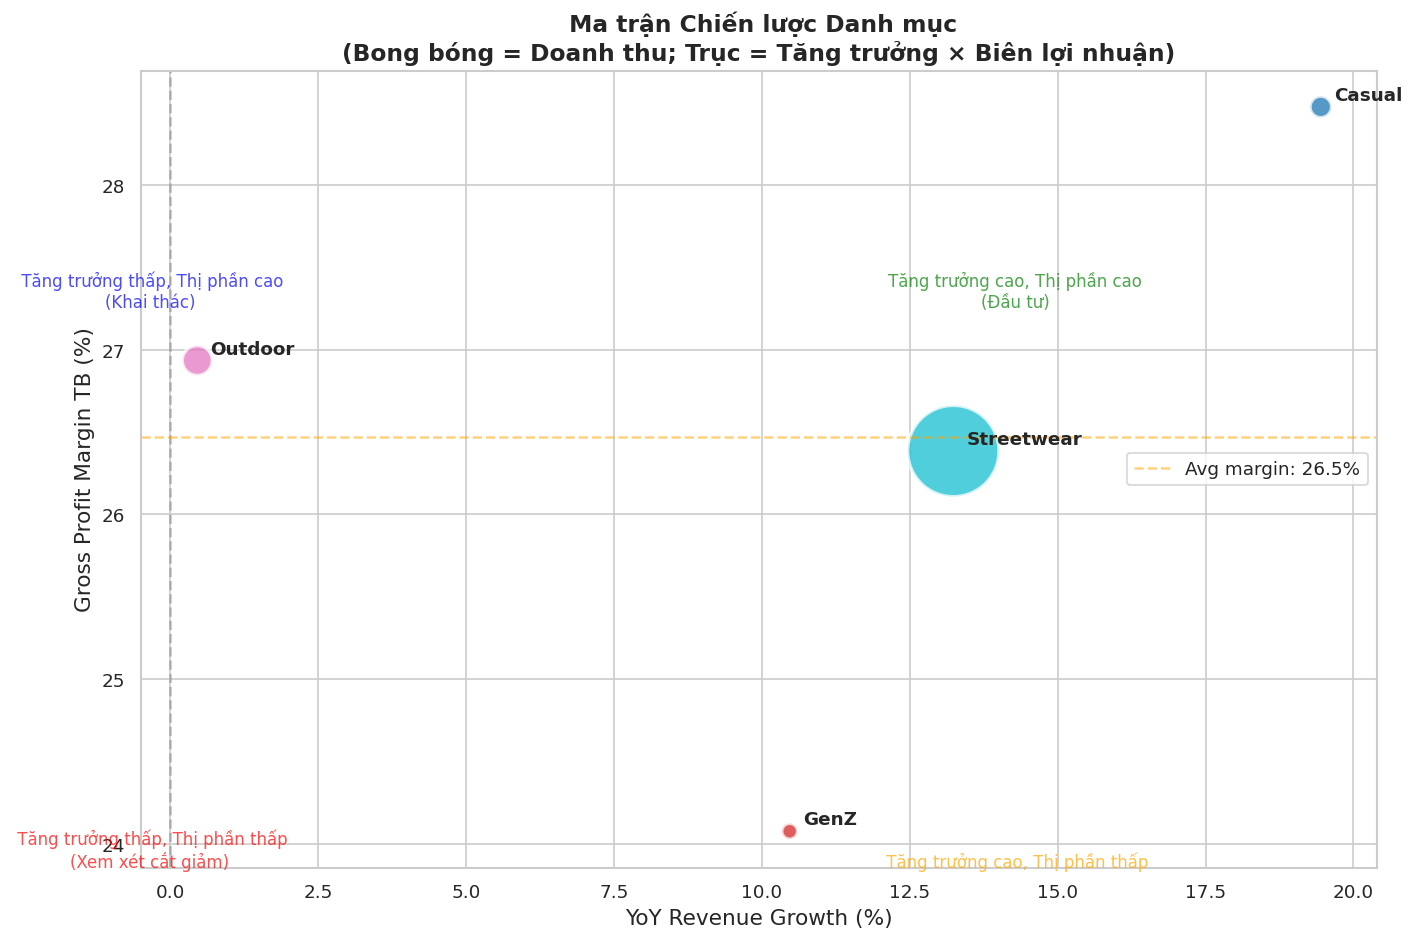

In [16]:
# YoY growth per category
oi_prod['order_year'] = oi_prod.merge(
    orders[['order_id','order_date']], on='order_id'
)['order_date'].dt.year

# Simpler: compute annual sales from orders
oi_ord = order_items.merge(products, on='product_id').merge(
    orders[['order_id','order_date']], on='order_id')
oi_ord['year'] = oi_ord['order_date'].dt.year
oi_ord['line_rev'] = oi_ord['unit_price'] * oi_ord['quantity']

cat_annual = oi_ord.groupby(['category','year'])['line_rev'].sum().reset_index()
last_2_years = sorted(cat_annual['year'].dropna().unique())[-2:]
cat_last2 = cat_annual[cat_annual['year'].isin(last_2_years)]
cat_pivot_y = cat_last2.pivot(index='category', columns='year', values='line_rev').fillna(0)

last_yr = cat_pivot_y.columns[-1]
prev_yr = cat_pivot_y.columns[-2]

cat_pivot_y['YoY_growth%'] = (cat_pivot_y[last_yr] - cat_pivot_y[prev_yr]) / cat_pivot_y[prev_yr] * 100
cat_pivot_y['avg_margin'] = products.groupby('category').apply(
    lambda d: ((d['price'] - d['cogs']) / d['price']).mean() * 100
)
cat_pivot_y['total_revenue'] = cat_pivot_y[last_yr]

fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(
    cat_pivot_y['YoY_growth%'],
    cat_pivot_y['avg_margin'],
    s=cat_pivot_y['total_revenue'] / cat_pivot_y['total_revenue'].max() * 3000,
    c=range(len(cat_pivot_y)),
    cmap='tab10', alpha=0.75, edgecolors='white', linewidth=2
)

for cat, row in cat_pivot_y.iterrows():
    ax.annotate(cat, (row['YoY_growth%'], row['avg_margin']),
                textcoords='offset points', xytext=(8, 4), fontsize=11, fontweight='bold')

ax.axvline(0, linestyle='--', color='gray', alpha=0.5)
ax.axhline(cat_pivot_y['avg_margin'].mean(), linestyle='--', color='orange', alpha=0.5,
           label=f"Avg margin: {cat_pivot_y['avg_margin'].mean():.1f}%")

ax.set_xlabel('YoY Revenue Growth (%)', fontsize=13)
ax.set_ylabel('Gross Profit Margin TB (%)', fontsize=13)
ax.set_title(' Ma trận Chiến lược Danh mục\n(Bong bóng = Doanh thu; Trục = Tăng trưởng × Biên lợi nhuận)',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=11)

# Quadrant labels
xlim = ax.get_xlim(); ylim = ax.get_ylim()
ax.text(xlim[1]*0.7, ylim[1]*0.95, 'Tăng trưởng cao, Thị phần cao\n(Đầu tư)', fontsize=10,
        color='green', ha='center', alpha=0.7)
ax.text(xlim[0]*0.7, ylim[1]*0.95, ' Tăng trưởng thấp, Thị phần cao\n(Khai thác)', fontsize=10,
        color='blue', ha='center', alpha=0.7)
ax.text(xlim[1]*0.7, ylim[0]*0.99995, ' Tăng trưởng cao, Thị phần thấp', fontsize=10,
        color='orange', ha='center', alpha=0.7)
ax.text(xlim[0]*0.7, ylim[0]*0.99995, ' Tăng trưởng thấp, Thị phần thấp\n(Xem xét cắt giảm)', fontsize=10,
        color='red', ha='center', alpha=0.7)

plt.tight_layout()
plt.savefig('./eda_graph/fig13_strategy_matrix.png', bbox_inches='tight')
plt.show()

 Các biểu đồ đã được lưu:
  fig01_revenue_overview.png     — Tổng quan doanh thu\
  fig02_seasonality.png          — Tính mùa vụ\
  fig03_product_analysis.png     — Danh mục & biên lợi nhuận\
  fig04_customer_behavior.png    — Hành vi khách hàng\
  fig05_web_traffic.png          — Phân tích traffic\
  fig06_promo_impact.png         — Tác động khuyến mãi\
  fig07_returns_analysis.png     — Phân tích trả hàng\
  fig08_cohort_retention.png     — Cohort retention\
  fig09_rfm.png                  — RFM segmentation\
  fig10_decomposition.png        — Seasonal decomposition\
  fig11_traffic_revenue_corr.png — Lag correlation\
  fig12_inventory.png            — Inventory analysis\
  fig13_strategy_matrix.png      — BCG strategy matrix
